Found 4013 images belonging to 51 classes.
Found 456 images belonging to 51 classes.
Found 474 images belonging to 51 classes.
Epoch 1/30
 4/31 [==>...........................] - ETA: 3:33 - loss: 3.7951 - accuracy: 0.1406

C:\Users\jabuu\anaconda3\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


31/31 [==============================] - 294s 9s/step - loss: 1.8460 - accuracy: 0.5220 - val_loss: 0.4995 - val_accuracy: 0.8620
Epoch 2/30
31/31 [==============================] - 278s 9s/step - loss: 0.6721 - accuracy: 0.8013 - val_loss: 0.3487 - val_accuracy: 0.9141
Epoch 3/30
31/31 [==============================] - 265s 9s/step - loss: 0.4457 - accuracy: 0.8641 - val_loss: 0.2726 - val_accuracy: 0.9453
Epoch 4/30
31/31 [==============================] - 267s 9s/step - loss: 0.3385 - accuracy: 0.8955 - val_loss: 0.2207 - val_accuracy: 0.9453
Epoch 5/30
31/31 [==============================] - 267s 9s/step - loss: 0.2264 - accuracy: 0.9318 - val_loss: 0.2305 - val_accuracy: 0.9479
Epoch 6/30
31/31 [==============================] - 269s 9s/step - loss: 0.1805 - accuracy: 0.9485 - val_loss: 0.1677 - val_accuracy: 0.9635
Epoch 7/30
31/31 [==============================] - 276s 9s/step - loss: 0.1396 - accuracy: 0.9606 - val_loss: 0.1906 - val_accuracy: 0.9661
Epoch 8/30
31/31 [======

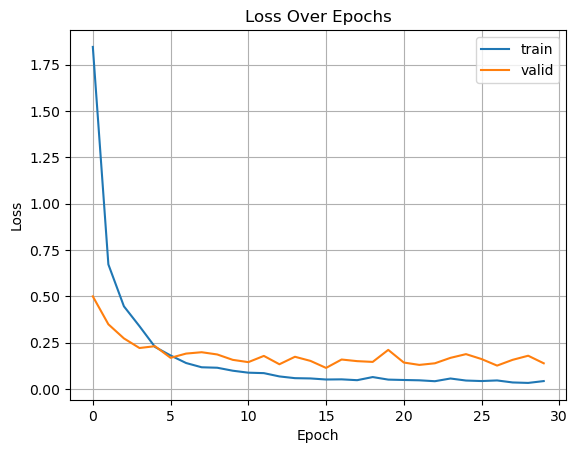

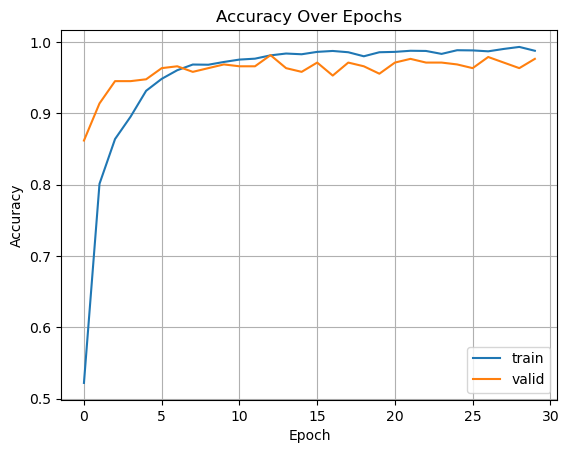

4/4 [==============================] - 55s 15s/step
                            precision    recall  f1-score   support

                     apple       0.00      0.00      0.00       8.0
         apple\Image_1.jpg       0.00      0.00      0.00       0.0
        apple\Image_10.jpg       0.00      0.00      0.00       0.0
         apple\Image_2.jpg       0.00      0.00      0.00       0.0
         apple\Image_3.jpg       0.00      0.00      0.00       0.0
         apple\Image_4.jpg       0.00      0.00      0.00       0.0
         apple\Image_5.jpg       0.00      0.00      0.00       0.0
         apple\Image_6.JPG       0.00      0.00      0.00       0.0
         apple\Image_7.jpg       0.00      0.00      0.00       0.0
         apple\Image_8.jpg       0.00      0.00      0.00       0.0
         apple\Image_9.jpg       0.00      0.00      0.00       0.0
                    banana       0.00      0.00      0.00       7.0
        banana\Image_1.jpg       0.00      0.00      0.00      

C:\Users\jabuu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jabuu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jabuu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jabuu\anaconda3\lib\site-packages\sklearn\metrics\_cla

 5/47 [==>...........................] - ETA: 4s

C:\Users\jabuu\anaconda3\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


47/47 [==============================] - 4s 78ms/step

DNN Final Results

Which of these are vegetables, fruits, or not a type of produce?

Fruits: ['watermelon', 'cherry', 'apple', 'orange', 'raspberry', 'jackfruit', 'papaya', 'cherry', 'grapes', 'orange', 'kiwi', 'plum', 'strawberry', 'mango', 'blackberry', 'banana', 'pomegranate', 'lemon', 'strawberry', 'pear']

Vegetables: ['beetroot', 'sweetpotato', 'cauliflower', 'cabbage', 'corn', 'chilli pepper', 'bell pepper', 'cucumber', 'carrot', 'ginger', 'peas', 'garlic', 'potato', 'eggplant', 'paprika', 'onion', 'lettuce', 'capsicum', 'rutabaga', 'parsnip', 'mushroom']

Not a type of produce: ['unknown', 'soy beans', 'jalepeno', 'raddish', 'olive', 'unknown']


In [ ]:
"""
Fruit and Vegetable Classification using Deep Neural Networks

Author: Justin Ogle

Description:
This project evaluates a Deep Neural Network (DNN) architecture
for classifying 51 categories of fruits and vegetables.

Features:
- Image preprocessing
- Data augmentation
- Deep learning classification
- Performance comparison against CNN and MLP approaches

Purpose:
To compare DNN performance against CNN and MLP models
for produce image classification.

Dataset:
Fruit and Vegetable Image Recognition Dataset (Kaggle)
Expanded from 36 to 51 classes.
"""

import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Define constants
num_classes = 51

# Define image directories
from pathlib import Path

DATASET_PATH = Path("dataset")

train_dir = DATASET_PATH / "train"
valid_dir = DATASET_PATH / "validation"
test_dir = DATASET_PATH / "test"
imgTest_dir = DATASET_PATH / "imgTest"

def create_model():
    # Create a model using MobileNetV2 as the base model
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers on top of the base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation="relu")(x)
    predictions = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def train_model(model, train_gen, val_gen, epochs):
    # Train the model
    history = model.fit(
        train_gen,
        steps_per_epoch=train_gen.samples // train_gen.batch_size,
        validation_data=val_gen,
        validation_steps=val_gen.samples // val_gen.batch_size,
        epochs=epochs
    )
    return history


def test_model(model, test_gen):
    # Test the model and return predictions
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    return y_pred

def classify_images(y_pred, pred_classes):
    # Classify predicted labels into specific categories
    classified_labels = []
    for label_idx in y_pred:
        if label_idx in pred_classes:
            classified_labels.append(pred_classes[label_idx])
        else:
            classified_labels.append("unknown")
    return classified_labels

def main():
    # Data augmentation for training and validation sets
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    validation_datagen = ImageDataGenerator(
        rescale=1./255
    )

    test_datagen = ImageDataGenerator(
        rescale=1./255
    )

    # Load and preprocess training, validation, and test data
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224),
        batch_size=128,
        class_mode="categorical"
    )

    validation_generator = validation_datagen.flow_from_directory(
        valid_dir,
        target_size=(224, 224),
        batch_size=128,
        class_mode="categorical"
    )

    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=128,
        class_mode="categorical",
        shuffle=False
    )

    # Define class labels
    pred_classes = {
        0 : "apple",
        1 : "banana",
        2 : "beetroot",
        3 : "bell pepper",
        4 : "blackberry",
        5 : "blueberry",
        6 : "cabbage",
        7 : "capsicum",
        8 : "carrot",
        9 : "cauliflower",
        10 : "cherry",
        11 : "chilli pepper",
        12 : "corn",
        13 : "cucumber",
        14 : "dragonfruit",
        15 : "eggplant",
        16 : "garlic",
        17 : "ginger",
        18 : "grapes",
        19 : "jalepeno",
        20 : "jackfruit",
        21 : "jalepeno",
        22 : "kiwi",
        23 : "lemon",
        24 : "lettuce",
        25 : "mango",
        26 : "mushroom",
        27 : "olive",
        28 : "onion",
        29 : "orange",
        30 : "papaya",
        31 : "paprika",
        32 : "parsnip",
        33 : "pear",
        34 : "peas",
        35 : "pineapple",
        36 : "plum",
        37 : "pomegranate",
        38 : "potato",
        39 : "raddish",
        40 : "raspberry",
        41 : "rutabaga",
        42 : "soy beans",
        43 : "spinach",
        44 : "strawberry",
        45 : "sweetcorn",
        46 : "sweetpotato",
        47 : "tomato",
        48 : "turnip",
        49 : "unknown",
        50 : "watermelon"
    }

    model = create_model()
    history = train_model(model, train_generator, validation_generator, epochs=30)
    history_df = pd.DataFrame(history.history)  # Create the history DataFrame
    history_df.head()  # Display the head of the DataFrame

    # Plot loss history
    plt.figure()
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["train", "valid"])
    plt.title("Loss Over Epochs")
    plt.grid(True)  # Add a grid
    plt.show()
    
    # Plot Accuracy history
    plt.figure()
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["train", "valid"])
    plt.title("Accuracy Over Epochs")
    plt.grid(True)  # Add a grid
    plt.show()
    
    y_pred = test_model(model, test_generator)
    classified_labels = classify_images(y_pred, pred_classes)
    print(classification_report(classified_labels, test_generator.filenames))

    # Additional code for imgTest data classification and printing results
    imgTest_datagen = ImageDataGenerator(
        rescale=1./255
    )

    imgTest_generator = imgTest_datagen.flow_from_directory(
        imgTest_dir,
        target_size=(224, 224),
        batch_size=1,
        class_mode="categorical",
        shuffle=False
    )

    img_pred = test_model(model, imgTest_generator)
    img_classified_labels = classify_images(img_pred, pred_classes)

    # Classify the results into vegetables, fruits, and unknown categories
    vegetables = []
    fruits = []
    unknown = []

    for label in img_classified_labels:
        if label in pred_classes.values():
            if label in ["beetroot", "bell pepper", "cabbage", "capsicum", "carrot", "cauliflower", "chilli pepper", "corn", "cucumber", "eggplant", "garlic", "ginger", "jalapeno", "lettuce", "mushroom", "olives", "onion", "paprika", "parsnip", "peas", "potato", "radish", "rutabaga", "soybeans", "spinach", "sweetpotato", "sweetcorn", "tomato", "turnip"]:
                vegetables.append(label)
            elif label in ["apple", "banana", "blackberry", "blueberry", "cherry", "dragonfruit", "grapes", "honeydew", "jackfruit", "kiwi", "lemon", "mango", "orange", "papaya", "pear", "pineapple", "pomegranate", "plum", "raspberry", "strawberry", "watermelon"]:
                fruits.append(label)
            else:
                unknown.append(label)

    # Print the results
    print("")
    print("DNN Final Results")
    print("")
    print("Which of these are vegetables, fruits, or not a type of produce?")
    print("")
    print("Fruits:", fruits)
    print("")
    print("Vegetables:", vegetables)
    print("")
    print("Not a type of produce:", unknown)

if __name__ == "__main__":
    main()